# Data Quality Assessment & Preprocessing – Assignment
ARTI308 Machine Learning
Student: Reema AlMulla

In [6]:
import pandas as pd

df = pd.read_csv("lab4_ML/Chocolate_Sales.csv")

df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("lab4_ML/Chocolate_Sales.csv")
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [9]:
df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True).astype(float)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df.dtypes

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\r2005\AppData\Local\Temp\ipykernel_31848\2841262291.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True).astype(float)


Sales Person                str
Country                     str
Product                     str
Date             datetime64[us]
Amount                  float64
Boxes Shipped             int64
dtype: object

## Task 1: Identify Data Quality Issues

In [10]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   str           
 1   Country        3282 non-null   str           
 2   Product        3282 non-null   str           
 3   Date           1290 non-null   datetime64[us]
 4   Amount         3282 non-null   float64       
 5   Boxes Shipped  3282 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 154.0 KB


,Date,Amount,Boxes Shipped
count,1290,3282.000000,3282.000000
mean,2023-06-25 18:39:37.674418,6030.338775,164.666971
min,2022-01-02 00:00:00,7.000000,1.000000
25%,2022-10-03 00:00:00,2521.495000,71.000000
50%,2023-07-02 00:00:00,5225.500000,137.000000
75%,2024-04-03 00:00:00,8556.842500,232.000000
max,2024-12-08 00:00:00,26170.950000,778.000000
std,NaN,4393.980200,124.024736


The dataset contains 3282 records and 6 columns. After preprocessing, the data types were corrected so that the `Date` column is stored as datetime and the `Amount` column is stored as a numeric value. The dataset shows that the `Date` column contains many missing values, while the other columns do not contain missing values. Additionally, the summary statistics suggest that the `Amount` column may contain outliers because the maximum value is much larger than the average.

## Task 2: Handle Missing Values

To demonstrate missing value handling, missing values were intentionally introduced into the `Amount` column. These missing values were then handled using **median imputation**. The median was chosen because it is more robust to outliers compared to the mean, making it a better choice for numerical data that may contain extreme values.

In [11]:
import numpy as np

df_missing = df.copy()

df_missing.loc[0:5, 'Amount'] = np.nan

df_missing.isnull().sum()

Sales Person        0
Country             0
Product             0
Date             1992
Amount              6
Boxes Shipped       0
dtype: int64

In [12]:
df_missing['Amount'] = df_missing['Amount'].fillna(df_missing['Amount'].median())

df_missing.isnull().sum()

Sales Person        0
Country             0
Product             0
Date             1992
Amount              0
Boxes Shipped       0
dtype: int64

The missing values in the `Amount` column were replaced using the **median value** of the column. Median imputation was used because it is less sensitive to extreme values and outliers compared to the mean.

## Task 3: Detect and Handle Outliers Using IQR

In [13]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 50


In [14]:
df_no_outliers = df[(df['Amount'] >= lower_bound) & (df['Amount'] <= upper_bound)]

print("Original dataset shape:", df.shape)
print("Dataset without outliers:", df_no_outliers.shape)

Original dataset shape: (3282, 6)
Dataset without outliers: (3232, 6)


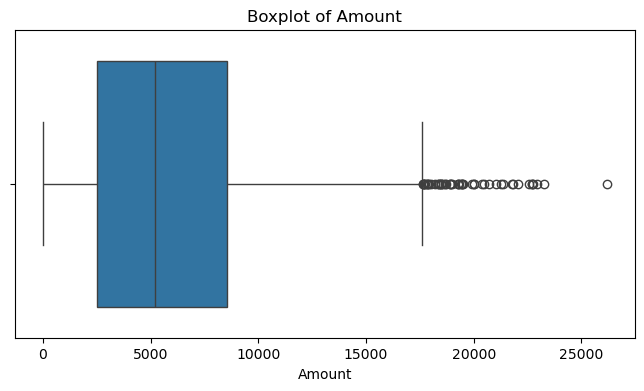

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Amount'])
plt.title("Boxplot of Amount")
plt.show()

The IQR (Interquartile Range) method was used to detect outliers in the `Amount` column. Values below the lower bound or above the upper bound were considered outliers. These extreme values were identified and removed to reduce their impact on the dataset.

## Task 4: Normalize Numerical Features

In [17]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 4.2 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.0 MB 6.7 MB/s eta 0:00:01
   -------------------------- ------------- 5.2/8.0 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 9.6 MB/s  0:00:01

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- ----------

In [18]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [19]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

numerical_features = df[['Amount', 'Boxes Shipped']]

# Min-Max scaling
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(numerical_features),
    columns=numerical_features.columns
)

print("Min-Max Scaled Data:")
display(df_minmax.head())

# Z-score standardization
standard_scaler = StandardScaler()
df_zscore = pd.DataFrame(
    standard_scaler.fit_transform(numerical_features),
    columns=numerical_features.columns
)

print("Z-score Standardized Data:")
display(df_zscore.head())

Min-Max Scaled Data:


,Amount,Boxes Shipped
0,0.203066,0.230373
1,0.301522,0.119691
2,0.171763,0.115830
3,0.486127,0.438867
4,0.522780,0.235521


Z-score Standardized Data:


,Amount,Boxes Shipped
0,-0.161686,0.123648
1,0.424660,-0.569868
2,-0.348106,-0.594061
3,1.524058,1.430038
4,1.742345,0.155904


Min-Max normalization and Z-score standardization were applied to the numerical features `Amount` and `Boxes Shipped`. Min-Max scaling transforms the values to a range between 0 and 1, while Z-score standardization scales the data so that it has a mean of 0 and a standard deviation of 1.

## Task 5: Check Correlation and Apply PCA

In [20]:
numerical_features = df[['Amount', 'Boxes Shipped']]

corr_matrix = numerical_features.corr()
corr_matrix

,Amount,Boxes Shipped
Amount,1.000000,-0.013154
Boxes Shipped,-0.013154,1.000000


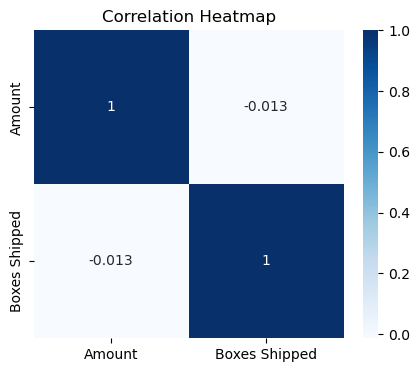

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

In [22]:
from sklearn.decomposition import PCA

# Use the Z-score scaled data from Task 4
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_zscore)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50657693 0.49342307]


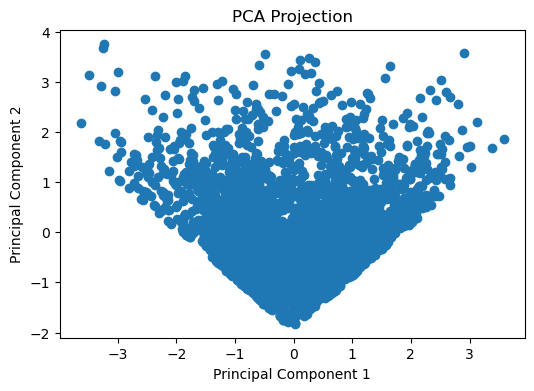

In [23]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.show()

The correlation between the numerical features was checked before applying PCA. PCA is most useful when features are correlated because it reduces redundancy between variables. After checking the correlation matrix, PCA was applied to transform the data into two principal components and examine the explained variance.